# Phase 3B: Model Architecture & Initial Training

**Project**: Neural PK-PD Modeling with Physics-Informed Neural ODEs  
**Date**: February 24, 2026  
**Previous Phase**: [phase3a_feature_engineering.ipynb](phase3a_feature_engineering.ipynb)  
**Next Phase**: [phase3c_finetuning.ipynb](phase3c_finetuning.ipynb)  

---

## 🎯 Phase 3B Objectives

1. **Multi-Task Neural Architecture** — Shared encoder with task-specific heads
2. **Neural ODE Integration** — Learn PK dynamics using `torchdiffeq`
3. **Physics-Informed Loss** — Incorporate mechanistic constraints
4. **Initial Training Run** — Baseline metrics on 4 prediction tasks

### Target Metrics

| Task | Metric | Target |
|------|--------|--------|
| Binding Affinity | R² | > 0.6 |
| hERG Inhibition | AUROC | > 0.8 |
| Caco-2 Permeability | AUROC | > 0.75 |
| Clearance | RMSE | < 1.0 |


---
## 1. Environment Setup & Load Phase 3A Artifacts


In [1]:
# ============================================
# IMPORTS & LOAD PHASE 3A ARTIFACTS
# ============================================

# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Neural ODE
from torchdiffeq import odeint

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    roc_auc_score, accuracy_score, f1_score, classification_report, roc_curve
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import pickle, os, json as _json, datetime, platform, sys

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')

# ── Execution Timestamp Logger ──────────────────────────────────
CELL_EXEC_LOG: list = []

def log_cell_start(section: str) -> None:
    now = datetime.datetime.now()
    CELL_EXEC_LOG.append({'section': section, 'start': now, 'end': None, 'duration_s': None})
    print(f'\u23f1  [{now.strftime("%Y-%m-%d %H:%M:%S")}] Starting: {section}')

def log_cell_end() -> None:
    now = datetime.datetime.now()
    if CELL_EXEC_LOG and CELL_EXEC_LOG[-1]['end'] is None:
        entry = CELL_EXEC_LOG[-1]
        entry['end'] = now
        entry['duration_s'] = round((now - entry['start']).total_seconds(), 2)
        print(f'\u23f1  [{now.strftime("%Y-%m-%d %H:%M:%S")}] Completed in {entry["duration_s"]:.1f}s')

def log_elapsed(label: str) -> None:
    elapsed = (datetime.datetime.now() - SESSION_START).total_seconds()
    h, rem = divmod(int(elapsed), 3600)
    m, s = divmod(rem, 60)
    print(f'\u23f1  [{label}] Elapsed: {h}h {m}m {s}s')

SESSION_START = datetime.datetime.now()

# ── Load Phase 3A Artifacts ────────────────────────────────────
log_cell_start('Load Phase 3A Artifacts')

ARTIFACT_DIR = 'data/processed/phase3a_artifacts'

with open(os.path.join(ARTIFACT_DIR, 'tasks_raw.pkl'), 'rb') as f:
    tasks_raw = pickle.load(f)

with open(os.path.join(ARTIFACT_DIR, 'task_types.pkl'), 'rb') as f:
    task_types = pickle.load(f)

with open(os.path.join(ARTIFACT_DIR, 'config.json'), 'r') as f:
    config = _json.load(f)

with open(os.path.join(ARTIFACT_DIR, 'scalers.pkl'), 'rb') as f:
    scaler_data = pickle.load(f)
    feat_scalers = scaler_data['feat_scalers']
    target_scalers = scaler_data['target_scalers']

with open(os.path.join(ARTIFACT_DIR, 'feature_meta.pkl'), 'rb') as f:
    feature_meta = pickle.load(f)
    FEATURE_COLS = feature_meta['FEATURE_COLS']
    PHYSICO_FEATURES = feature_meta['PHYSICO_FEATURES']
    FINGERPRINT_COLS = feature_meta['FINGERPRINT_COLS']
    N_BITS = feature_meta['N_BITS']
    FEAT_DIM = feature_meta['FEAT_DIM']

quality_df = pd.read_csv(os.path.join(ARTIFACT_DIR, 'quality_gate.csv'))
phase2_features = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'phase2_features.parquet'))

print(f'\n\u2705 Phase 3A artifacts loaded from {ARTIFACT_DIR}/')
print(f'   Tasks: {list(tasks_raw.keys())}')
print(f'   Config input_dim: {config["input_dim"]}')
print(f'   Feature columns: {len(FEATURE_COLS)}')
for task, (X, y) in tasks_raw.items():
    print(f'   {task}: X={X.shape}, y={y.shape}')

log_cell_end()


PyTorch version: 2.10.0
Device: cpu
⏱  [2026-03-22 17:45:54] Starting: Load Phase 3A Artifacts

✅ Phase 3A artifacts loaded from data/processed/phase3a_artifacts/
   Tasks: ['binding', 'herg', 'caco2', 'clearance']
   Config input_dim: 2050
   Feature columns: 2050
   binding: X=(2000, 2050), y=(2000,)
   herg: X=(655, 2050), y=(655,)
   caco2: X=(900, 2050), y=(900,)
   clearance: X=(1213, 2050), y=(1213,)
⏱  [2026-03-22 17:45:54] Completed in 0.2s


---
## 3.5  Structure → Binding → PK Bridge: Feature Augmentation

This cell closes the thesis chain:

```
SMILES + real PDB pocket
    ↓  RapidDock Distance-Biased Transformer
predicted L–P geometry  →  docking_quality score
    ↓  joined on target_chembl_id
binding task feature matrix  [MW, LogP, fp_0..fp_2047, **docking_quality**]
    ↓  SharedEncoder
Neural ODE PK-PD model  →  CL, V, concentration–time curve
```

**What this cell does:**
1. Loads `data/outputs/structure_binding_pkpd_bridge.csv` (produced by the RapidDock notebook)
2. Computes per-target mean `docking_quality` (RapidDock geometry average for each of the 8 ChEMBL protein targets)
3. Rebuilds the binding affinity task from `data/raw/chembl/chembl_binding_affinity_with_smiles.csv`
   — the same 8 targets the bridge was built from — computing RDKit Morgan fingerprints and appending `docking_quality`
4. Pads the three ADMET tasks (hERG, Caco-2, clearance) with `docking_quality = 0.0`
   (these assays have no single protein-target context equivalent to the bridge targets)
5. Updates `config['input_dim']` from 2050 → 2051


In [2]:

# ============================================
# STRUCTURE → BINDING BRIDGE: Augment binding task with docking_quality
# Appends RapidDock-predicted structural quality as feature 2051
# ============================================
log_cell_start('Bridge Augmentation: +docking_quality (2050 → 2051)')

from rdkit import Chem
from rdkit.Chem import AllChem, Crippen, rdMolDescriptors

BRIDGE_CSV = 'data/outputs/structure_binding_pkpd_bridge.csv'
CHEMBL_CSV = 'data/raw/chembl/chembl_binding_affinity_with_smiles.csv'
N_FP_BITS  = 2048

# ── 1. Per-target mean docking quality from RapidDock bridge ─────────────────
bridge_df = pd.read_csv(BRIDGE_CSV)
target_dq = bridge_df.groupby('target_chembl_id')['docking_quality'].mean().to_dict()
print("Per-target mean docking_quality (from RapidDock bridge):")
for t, v in sorted(target_dq.items()):
    print(f"  {t}: {v:+.4f}")

# ── 2. Rebuild binding task from raw ChEMBL data ─────────────────────────────
# The ChEMBL CSV (same 8 targets as bridge) has SMILES + target_chembl_id
chembl_df = pd.read_csv(CHEMBL_CSV).dropna(subset=['smiles', 'pchembl_value', 'target_chembl_id'])

def smiles_to_features(smi, dq_val, n_bits=N_FP_BITS):
    """MW + LogP + Morgan 2048-bit + docking_quality (2051 features total)."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    gen = AllChem.GetMorganGenerator(radius=2, fpSize=n_bits)
    fp  = list(gen.GetFingerprintAsNumPy(mol))
    mw   = rdMolDescriptors.CalcExactMolWt(mol)
    logp = Crippen.MolLogP(mol)
    return [mw, logp] + fp + [float(dq_val)]

rows_X, rows_y = [], []
skipped = 0
for _, row in chembl_df.iterrows():
    dq  = target_dq.get(row['target_chembl_id'], 0.0)
    vec = smiles_to_features(row['smiles'], dq)
    if vec is None:
        skipped += 1
        continue
    rows_X.append(vec)
    rows_y.append(float(row['pchembl_value']))

X_binding_aug = np.array(rows_X, dtype=np.float32)
y_binding_aug = np.array(rows_y, dtype=np.float32)

print(f"\nAugmented binding dataset: {len(rows_X)} compounds  (skipped {skipped} invalid SMILES)")
print(f"  X shape: {X_binding_aug.shape}  →  [MW, LogP, fp_0..fp_{N_FP_BITS-1}, docking_quality]")
print(f"  y range: [{y_binding_aug.min():.2f}, {y_binding_aug.max():.2f}] pChEMBL")

# ── 3. Pad ADMET tasks with docking_quality = 0.0 (no specific protein target) ─
old_dim = list(tasks_raw.values())[0][0].shape[1]
augmented_tasks = {}
for task, (X, y) in tasks_raw.items():
    if task == 'binding':
        augmented_tasks[task] = (X_binding_aug, y_binding_aug)
    else:
        dq_col = np.zeros((len(X), 1), dtype=np.float32)
        augmented_tasks[task] = (np.hstack([X, dq_col]), y)
tasks_raw = augmented_tasks   # replace in-place for downstream cells

# ── 4. Update config and feature metadata ─────────────────────────────────────
new_dim = X_binding_aug.shape[1]
config['input_dim'] = new_dim
FEATURE_COLS = FEATURE_COLS + ['docking_quality']
FEAT_DIM     = new_dim

print(f"\nconfig['input_dim'] updated:  {old_dim} → {new_dim}")
print(f"FEATURE_COLS:                  {old_dim} → {len(FEATURE_COLS)} (last: '{FEATURE_COLS[-1]}')")

print("\nTasks after augmentation:")
for task, (X, y) in tasks_raw.items():
    dq_stats = X[:, -1]
    print(f"  {task:<12}: X={X.shape}, y={y.shape}  dq=[{dq_stats.min():.2f}, {dq_stats.max():.2f}]")

print("\n✅ Feature 2051 (docking_quality) appended to all tasks")
print("   Binding → per-target mean RapidDock geometry score")
print("   hERG / Caco-2 / clearance → 0.0  (ADMET assays, no single protein target)")

log_cell_end()


⏱  [2026-03-22 17:45:57] Starting: Bridge Augmentation: +docking_quality (2050 → 2051)
Per-target mean docking_quality (from RapidDock bridge):
  CHEMBL1871: -10.1107
  CHEMBL203: -8.4298
  CHEMBL2034: -10.1475
  CHEMBL210: -9.9595
  CHEMBL217: -9.3785
  CHEMBL251: -9.5536
  CHEMBL301: -9.4621
  CHEMBL325: -10.9955

Augmented binding dataset: 3410 compounds  (skipped 0 invalid SMILES)
  X shape: (3410, 2051)  →  [MW, LogP, fp_0..fp_2047, docking_quality]
  y range: [4.00, 10.52] pChEMBL

config['input_dim'] updated:  2050 → 2051
FEATURE_COLS:                  2050 → 2051 (last: 'docking_quality')

Tasks after augmentation:
  binding     : X=(3410, 2051), y=(3410,)  dq=[-11.00, -8.43]
  herg        : X=(655, 2051), y=(655,)  dq=[0.00, 0.00]
  caco2       : X=(900, 2051), y=(900,)  dq=[0.00, 0.00]
  clearance   : X=(1213, 2051), y=(1213,)  dq=[0.00, 0.00]

✅ Feature 2051 (docking_quality) appended to all tasks
   Binding → per-target mean RapidDock geometry score
   hERG / Caco-2 / clear

---
## 2. Rebuild DataLoaders

Reconstruct train/val/test DataLoaders from the saved task arrays and config.


In [3]:
# ============================================
# REBUILD DATALOADERS FROM SAVED ARTIFACTS
# ============================================
log_cell_start('Rebuild DataLoaders')

def compute_pos_weight(y_binary):
    y_binary = np.asarray(y_binary).astype(np.float32)
    pos = float((y_binary == 1).sum())
    neg = float((y_binary == 0).sum())
    if pos == 0:
        return 1.0
    return max(1.0, neg / pos)

def make_loaders(X, y, config, is_regression=True, random_state=42):
    X_tv, X_test, y_tv, y_test = train_test_split(
        X, y, test_size=config['test_size'], random_state=random_state)
    val_frac = config['val_size'] / (1 - config['test_size'])
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=val_frac, random_state=random_state)

    feat_scaler = StandardScaler()
    X_train = feat_scaler.fit_transform(X_train)
    X_val   = feat_scaler.transform(X_val)
    X_test  = feat_scaler.transform(X_test)

    target_scaler = None
    if is_regression:
        target_scaler = StandardScaler()
        y_train = target_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
        y_val   = target_scaler.transform(y_val.reshape(-1, 1)).flatten()
        y_test  = target_scaler.transform(y_test.reshape(-1, 1)).flatten()

    def to_loader(Xa, ya, shuffle=True):
        ds = TensorDataset(torch.FloatTensor(Xa), torch.FloatTensor(ya).unsqueeze(1))
        def collate(batch):
            Xb, yb = zip(*batch)
            return {'X': torch.stack(Xb), 'y': torch.stack(yb)}
        return DataLoader(ds, batch_size=config['batch_size'],
                          shuffle=shuffle, collate_fn=collate)

    return (to_loader(X_train, y_train, shuffle=True),
            to_loader(X_val,   y_val,   shuffle=False),
            to_loader(X_test,  y_test,  shuffle=False),
            feat_scaler, target_scaler)

train_loaders, val_loaders, test_loaders = {}, {}, {}
feat_scalers, target_scalers = {}, {}

for task, (X, y) in tasks_raw.items():
    tr, va, te, fs, ts = make_loaders(X, y, config, is_regression=task_types[task])
    train_loaders[task]   = tr
    val_loaders[task]     = va
    test_loaders[task]    = te
    feat_scalers[task]    = fs
    target_scalers[task]  = ts

print('DataLoaders rebuilt:')
for task, loader in train_loaders.items():
    n = len(loader.dataset)
    reg = 'regression' if task_types[task] else 'classification'
    print(f'  {task:<12}  {reg:<14}  train={n}, '
          f'val={len(val_loaders[task].dataset)}, '
          f'test={len(test_loaders[task].dataset)}')

log_cell_end()


⏱  [2026-03-22 17:46:10] Starting: Rebuild DataLoaders
DataLoaders rebuilt:
  binding       regression      train=2387, val=341, test=682
  herg          classification  train=458, val=66, test=131
  caco2         classification  train=630, val=90, test=180
  clearance     regression      train=848, val=122, test=243
⏱  [2026-03-22 17:46:10] Completed in 0.1s


---
## 5. Multi-Task Dataset Class

In [4]:

# ============================================
# MULTI-TASK DATASET
# ============================================
log_cell_start("Cell 09 - MultiTaskDataset")

class MultiTaskDataset(Dataset):
    """
    Dataset for multi-task learning with different sample sizes per task.
    """
    def __init__(self, task_data_dict):
        """
        Parameters:
        -----------
        task_data_dict : dict
            Dictionary with task names as keys, (X, y) tuples as values
        """
        self.tasks = list(task_data_dict.keys())
        self.data = task_data_dict
        
        # Total samples across all tasks
        self.total_samples = sum(len(v[0]) for v in task_data_dict.values())
        
        # Create index mapping: global_idx -> (task, local_idx)
        self.index_map = []
        for task in self.tasks:
            n_samples = len(self.data[task][0])
            for i in range(n_samples):
                self.index_map.append((task, i))
    
    def __len__(self):
        return self.total_samples
    
    def __getitem__(self, idx):
        task, local_idx = self.index_map[idx]
        X, y = self.data[task]
        return {
            'features': torch.FloatTensor(X[local_idx]),
            'target': torch.FloatTensor([y[local_idx]]),
            'task': task
        }

print("MultiTaskDataset class defined.")

log_cell_end()


⏱  [2026-03-22 17:46:17] Starting: Cell 09 - MultiTaskDataset
MultiTaskDataset class defined.
⏱  [2026-03-22 17:46:17] Completed in 0.0s


---
## 6. Neural Network Architecture

### 6.1 Shared Encoder

In [5]:

# ============================================
# SHARED ENCODER  (LayerNorm — safe for multi-task interleaved training)
# ============================================
log_cell_start("Cell 10 - Shared Encoder")

class SharedEncoder(nn.Module):
    """
    Shared feature encoder for all tasks.
    Uses LayerNorm instead of BatchNorm to avoid running-statistics
    corruption caused by interleaved multi-task batches.
    """
    def __init__(self, input_dim, hidden_dim, latent_dim, dropout=0.3):
        super(SharedEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, latent_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.encoder(x)

print("SharedEncoder defined (LayerNorm, safe for interleaved multi-task training).")

log_cell_end()


⏱  [2026-03-22 17:46:20] Starting: Cell 10 - Shared Encoder
SharedEncoder defined (LayerNorm, safe for interleaved multi-task training).
⏱  [2026-03-22 17:46:20] Completed in 0.0s


### 6.2 Task-Specific Heads

In [6]:

# ============================================
# TASK-SPECIFIC HEADS
# ============================================
log_cell_start("Cell 11 - Task Heads")

class RegressionHead(nn.Module):
    """Compact head for easier regression tasks (e.g., clearance)."""
    def __init__(self, latent_dim):
        super(RegressionHead, self).__init__()
        self.head = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.ReLU(),
            nn.Linear(latent_dim // 2, 1)
        )
    
    def forward(self, x):
        return self.head(x)


class DeepRegressionHead(nn.Module):
    """Deeper head for harder regression tasks (binding)."""
    def __init__(self, latent_dim, hidden_dim=64, dropout=0.1):
        super(DeepRegressionHead, self).__init__()
        self.head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, x):
        return self.head(x)


class ClassificationHead(nn.Module):
    """Binary classification head returning logits (hERG, Caco-2)."""
    def __init__(self, latent_dim):
        super(ClassificationHead, self).__init__()
        self.head = nn.Sequential(
            nn.Linear(latent_dim, latent_dim // 2),
            nn.ReLU(),
            nn.Linear(latent_dim // 2, 1)
        )
    
    def forward(self, x):
        return self.head(x)

print("Task heads defined: RegressionHead, DeepRegressionHead, ClassificationHead (logits)")

log_cell_end()


⏱  [2026-03-22 17:46:23] Starting: Cell 11 - Task Heads
Task heads defined: RegressionHead, DeepRegressionHead, ClassificationHead (logits)
⏱  [2026-03-22 17:46:23] Completed in 0.0s


### 6.3 Neural ODE Component

In [7]:

# ============================================
# NEURAL ODE FOR PK DYNAMICS
# ============================================
log_cell_start("Cell 12 - PKODEFunc")

class PKODEFunc(nn.Module):
    """
    Neural ODE function for pharmacokinetic dynamics.
    
    Models: dC/dt = f(C, molecular_features)
    
    Can learn clearance and volume parameters from molecular structure.
    """
    def __init__(self, latent_dim):
        super(PKODEFunc, self).__init__()
        
        # Network to predict PK parameters from latent features
        self.pk_params = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 2)  # [CL, V] predicted
        )
        
        # Latent features (set during forward pass)
        self.latent = None
    
    def set_latent(self, latent):
        """Set molecular latent features for ODE integration"""
        self.latent = latent
    
    def forward(self, t, C):
        """
        ODE dynamics: dC/dt = -k * C where k = CL/V
        
        Parameters:
        -----------
        t : tensor
            Time point
        C : tensor
            Concentration (batch_size, 1)
        """
        if self.latent is None:
            raise ValueError("Latent features not set. Call set_latent() first.")
        
        # Get PK parameters
        pk = self.pk_params(self.latent)
        CL = torch.exp(pk[:, 0:1])  # Ensure positive clearance
        V = torch.exp(pk[:, 1:2])   # Ensure positive volume
        k = CL / V
        
        # First-order elimination: dC/dt = -k * C
        dCdt = -k * C
        
        return dCdt

print("PKODEFunc defined for neural ODE PK modeling.")

log_cell_end()


⏱  [2026-03-22 17:46:26] Starting: Cell 12 - PKODEFunc
PKODEFunc defined for neural ODE PK modeling.
⏱  [2026-03-22 17:46:26] Completed in 0.0s


### 6.4 Complete Multi-Task Model

In [8]:

# ============================================
# MULTI-TASK PK-PD MODEL
# ============================================
log_cell_start("Cell 13 - Full Model")

class MultiTaskPKPDModel(nn.Module):
    """
    Complete multi-task model for PK-PD predictions.

    Architecture:
    - Shared encoder: molecular features → latent space
    - Task heads: latent → task-specific predictions
      * binding   → DeepRegressionHead
      * hERG      → ClassificationHead
      * caco2     → ClassificationHead
      * clearance → RegressionHead
    - Neural ODE: latent → PK time-course (optional)
    """
    def __init__(self, config):
        super(MultiTaskPKPDModel, self).__init__()

        input_dim  = config['input_dim']
        hidden_dim = config['hidden_dim']
        latent_dim = config['latent_dim']
        dropout    = config['dropout']

        # Shared encoder
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim, dropout)

        # Task-specific heads
        self.binding_head   = DeepRegressionHead(
            latent_dim,
            hidden_dim=config.get('reg_head_hidden', 64),
            dropout=config.get('reg_head_dropout', 0.1)
        )
        self.herg_head      = ClassificationHead(latent_dim)
        self.caco2_head     = ClassificationHead(latent_dim)
        self.clearance_head = RegressionHead(latent_dim)

        # Neural ODE for PK dynamics
        self.ode_func = PKODEFunc(latent_dim)

    def forward(self, x, task=None):
        latent = self.encoder(x)

        if task == 'binding':
            return self.binding_head(latent)
        elif task == 'herg':
            return self.herg_head(latent)
        elif task == 'caco2':
            return self.caco2_head(latent)
        elif task == 'clearance':
            return self.clearance_head(latent)
        elif task == 'all':
            return {
                'binding':   self.binding_head(latent),
                'herg':      self.herg_head(latent),
                'caco2':     self.caco2_head(latent),
                'clearance': self.clearance_head(latent),
                'latent':    latent,
            }
        else:
            return latent

    def predict_pk_curve(self, x, t_span, C0=1.0):
        latent = self.encoder(x)
        self.ode_func.set_latent(latent)
        C_init = torch.full((x.shape[0], 1), C0, device=x.device)
        C_t = odeint(self.ode_func, C_init, t_span)
        return C_t  # (time_points, batch_size, 1)

print("MultiTaskPKPDModel defined.")
print("\nModel components:")
print("  - SharedEncoder: features → latent")
print("  - DeepRegressionHead: binding")
print("  - RegressionHead:     clearance")
print("  - ClassificationHead: hERG, Caco-2")
print("  - PKODEFunc:          Neural ODE for PK curves")

log_cell_end()


⏱  [2026-03-22 17:46:29] Starting: Cell 13 - Full Model
MultiTaskPKPDModel defined.

Model components:
  - SharedEncoder: features → latent
  - DeepRegressionHead: binding
  - RegressionHead:     clearance
  - ClassificationHead: hERG, Caco-2
  - PKODEFunc:          Neural ODE for PK curves
⏱  [2026-03-22 17:46:29] Completed in 0.0s


In [9]:

# ============================================
# INSTANTIATE MODEL
# ============================================
log_cell_start("Cell 14 - Instantiate Model")

model = MultiTaskPKPDModel(config).to(device)

# Print model summary
print("Model Architecture:")
print("=" * 50)
print(model)
print("=" * 50)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

log_cell_end()


⏱  [2026-03-22 17:46:32] Starting: Cell 14 - Instantiate Model
Model Architecture:
MultiTaskPKPDModel(
  (encoder): SharedEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=2051, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): ReLU()
    )
  )
  (binding_head): DeepRegressionHead(
    (head): Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.1, inplace=False)
      (3): Linear(in_features=64, out_features=32, bias=True)
      (4): ReLU()
      (5): Linear(in_features=32, out_features=1, bias=True)
    )
  )
  (herg_head): ClassificationHead(
    (

---
## 7. Loss Functions

In [10]:

# ============================================
# MULTI-TASK LOSS FUNCTION
# ============================================
log_cell_start("Cell 15 - MultiTaskLoss")

class MultiTaskLoss(nn.Module):
    """
    Combined loss for multi-task learning.

    Loss = w_binding   * MSE(binding)
         + w_herg      * cls_loss(hERG)
         + w_caco2     * cls_loss(caco2)
         + w_clearance * MSE(clearance)
         + w_physics   * physics_penalty
    """
    def __init__(self, config):
        super(MultiTaskLoss, self).__init__()

        self.w_binding   = config['w_binding']
        self.w_herg      = config['w_herg']
        self.w_caco2     = config['w_caco2']
        self.w_clearance = config['w_clearance']
        self.w_physics   = config['w_physics']

        self.use_focal = config.get('use_focal_for_classification', True)
        self.focal_gamma = config.get('focal_gamma', 2.0)

        self.mse = nn.MSELoss()
        self.bce_logits = nn.BCEWithLogitsLoss(reduction='none')

        self.herg_pos_weight = torch.tensor([config.get('herg_pos_weight', 5.7)], dtype=torch.float32)
        self.caco2_pos_weight = torch.tensor([config.get('caco2_pos_weight', 1.0)], dtype=torch.float32)

    def _weighted_bce_logits(self, logits, targets, pos_weight):
        """BCEWithLogits with explicit positive-class weighting."""
        pos_w = pos_weight.to(logits.device)
        loss = self.bce_logits(logits, targets)
        sample_weight = torch.where(targets > 0.5, pos_w, torch.ones_like(targets))
        return (loss * sample_weight).mean()

    def _focal_logits_loss(self, logits, targets, pos_weight):
        """Binary focal loss computed from BCEWithLogits per sample."""
        pos_w = pos_weight.to(logits.device)
        bce = self.bce_logits(logits, targets)
        sample_weight = torch.where(targets > 0.5, pos_w, torch.ones_like(targets))
        pt = torch.exp(-bce)
        focal_factor = (1 - pt) ** self.focal_gamma
        return (sample_weight * focal_factor * bce).mean()

    def _classification_loss(self, logits, targets, pos_weight):
        if self.use_focal:
            return self._focal_logits_loss(logits, targets, pos_weight)
        return self._weighted_bce_logits(logits, targets, pos_weight)

    def forward(self, predictions, targets, task):
        if task == 'binding':
            return self.w_binding * self.mse(predictions, targets)
        elif task == 'herg':
            return self.w_herg * self._classification_loss(predictions, targets, self.herg_pos_weight)
        elif task == 'caco2':
            return self.w_caco2 * self._classification_loss(predictions, targets, self.caco2_pos_weight)
        elif task == 'clearance':
            return self.w_clearance * self.mse(predictions, targets)
        else:
            raise ValueError(f"Unknown task: {task}")

    def physics_penalty(self, pk_curve):
        neg_penalty       = torch.relu(-pk_curve).mean()
        dC                = pk_curve[1:] - pk_curve[:-1]
        increasing_penalty = torch.relu(dC).mean()
        return self.w_physics * (neg_penalty + increasing_penalty)

criterion = MultiTaskLoss(config)
loss_name = "focal logits loss" if config.get('use_focal_for_classification', True) else "weighted BCEWithLogits"
print(f"MultiTaskLoss defined ({loss_name} for hERG/Caco-2, MSE for binding/clearance).")

log_cell_end()


⏱  [2026-03-22 17:46:37] Starting: Cell 15 - MultiTaskLoss
MultiTaskLoss defined (focal logits loss for hERG/Caco-2, MSE for binding/clearance).
⏱  [2026-03-22 17:46:37] Completed in 0.0s


---
## 8. Training Pipeline

In [11]:

# ============================================
# TRAINING FUNCTION  (interleaved task sampling)
# ============================================
log_cell_start("Cell 16 - Train Epoch Fn")

def train_epoch(model, data_loaders, optimizer, criterion, device, grad_clip=1.0):
    """
    Train one epoch with interleaved task sampling at the MINIMUM task size.
    Each epoch = min(task_batches) steps; larger tasks subsample their data.
    This avoids cycling small tasks (caco2 only has 10 batches) many times.
    DataLoader shuffle=True ensures different samples each epoch.
    """
    model.train()
    task_losses = {task: [] for task in data_loaders.keys()}

    # Use min batch count so no task repeats within an epoch
    n_steps = min(len(loader) for loader in data_loaders.values())

    # Fresh iterators (loaders have shuffle=True so order differs each epoch)
    iters = {task: iter(loader) for task, loader in data_loaders.items()}

    for _step in range(n_steps):
        for task in data_loaders.keys():
            try:
                batch = next(iters[task])
            except StopIteration:
                iters[task] = iter(data_loaders[task])
                batch = next(iters[task])

            X = batch['X'].to(device)
            y = batch['y'].to(device)

            optimizer.zero_grad()
            pred = model(X, task=task)
            loss = criterion(pred, y, task)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            task_losses[task].append(loss.item())

    avg = {task: np.mean(losses) for task, losses in task_losses.items()}
    avg['total'] = sum(avg.values())
    return avg

print("Training function defined (min-step interleaving, gradient clipping).")

log_cell_end()


⏱  [2026-03-22 17:46:46] Starting: Cell 16 - Train Epoch Fn
Training function defined (min-step interleaving, gradient clipping).
⏱  [2026-03-22 17:46:46] Completed in 0.0s


In [12]:

# ============================================
# VALIDATION FUNCTION
# ============================================
log_cell_start("Cell 17 - Validate Fn")

REGRESSION_TASKS     = {'binding', 'clearance'}          # MSE/R² metrics
CLASSIFICATION_TASKS = {'herg', 'caco2'}                 # AUROC/accuracy metrics

def _best_threshold_by_youden(targets, probs):
    """Select threshold maximizing TPR-FPR on validation set."""
    if len(np.unique(targets)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(targets, probs)
    j = tpr - fpr
    best_idx = int(np.argmax(j))
    thr = thresholds[best_idx]
    if not np.isfinite(thr):
        return 0.5
    return float(np.clip(thr, 0.01, 0.99))

def validate(model, data_loaders, criterion, device):
    """
    Validate model on all tasks.
    Returns dict of per-task losses and metrics.
    """
    model.eval()
    results = {}

    with torch.no_grad():
        for task, loader in data_loaders.items():
            all_preds, all_targets, task_loss = [], [], []

            for batch in loader:
                X = batch['X'].to(device)
                y = batch['y'].to(device)

                pred = model(X, task=task)
                loss = criterion(pred, y, task)

                task_loss.append(loss.item())
                if task in CLASSIFICATION_TASKS:
                    pred_for_metrics = torch.sigmoid(pred)
                else:
                    pred_for_metrics = pred
                all_preds.extend(pred_for_metrics.cpu().numpy().flatten())
                all_targets.extend(y.cpu().numpy().flatten())

            preds   = np.array(all_preds)
            targets = np.array(all_targets)

            if task in REGRESSION_TASKS:
                results[task] = {
                    'loss': np.mean(task_loss),
                    'rmse': np.sqrt(mean_squared_error(targets, preds)),
                    'r2':   r2_score(targets, preds),
                    'mae':  mean_absolute_error(targets, preds),
                }
            else:  # classification
                threshold = _best_threshold_by_youden(targets, preds)
                binary_preds = (preds > threshold).astype(int)
                results[task] = {
                    'loss':      np.mean(task_loss),
                    'auroc':     roc_auc_score(targets, preds) if len(np.unique(targets)) > 1 else 0.5,
                    'accuracy':  accuracy_score(targets, binary_preds),
                    'f1':        f1_score(targets, binary_preds, zero_division=0),
                    'threshold': threshold,
                }

    return results

print("Validation function defined (logits model + sigmoid metrics + threshold tuning).")

log_cell_end()


⏱  [2026-03-22 17:46:50] Starting: Cell 17 - Validate Fn
Validation function defined (logits model + sigmoid metrics + threshold tuning).
⏱  [2026-03-22 17:46:50] Completed in 0.0s


In [13]:

# ============================================
# FULL TRAINING LOOP
# ============================================
log_cell_start("Cell 18 - Train Model Fn")

def train_model(model, train_loaders, val_loaders, config, device):
    """Full training loop with early stopping."""
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=8
    )

    criterion = MultiTaskLoss(config)
    grad_clip  = config.get('grad_clip', 1.0)

    history = {'train_loss': [], 'val_loss': [], 'val_metrics': []}
    best_val_loss = float('inf')
    patience_counter = 0

    print(f"Starting training for up to {config['epochs']} epochs "
          f"(patience={config['patience']})...")
    print("=" * 65)

    for epoch in range(config['epochs']):
        train_losses = train_epoch(model, train_loaders, optimizer, criterion,
                                   device, grad_clip=grad_clip)
        val_results  = validate(model, val_loaders, criterion, device)
        val_loss     = sum(r['loss'] for r in val_results.values())

        scheduler.step(val_loss)

        history['train_loss'].append(train_losses['total'])
        history['val_loss'].append(val_loss)
        history['val_metrics'].append(val_results)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{config['epochs']}")
            print(f"  Train Loss: {train_losses['total']:.4f}  "
                  f"Val Loss: {val_loss:.4f}")
            for task, metrics in val_results.items():
                if 'r2' in metrics:
                    print(f"    {task:<10}: R\u00b2={metrics['r2']:.3f}, "
                          f"RMSE={metrics['rmse']:.3f}")
                else:
                    print(f"    {task:<10}: AUROC={metrics['auroc']:.3f}, "
                          f"Acc={metrics['accuracy']:.3f}, Thr={metrics['threshold']:.2f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    print(f"\nTraining complete! Best val loss: {best_val_loss:.4f}")
    model.load_state_dict(torch.load('best_model.pt', weights_only=True))
    return model, history

print("Training loop defined.")

log_cell_end()


⏱  [2026-03-22 17:46:57] Starting: Cell 18 - Train Model Fn
Training loop defined.
⏱  [2026-03-22 17:46:57] Completed in 0.0s


---
## 9. Visualization Functions

In [14]:

# ============================================
# TRAINING VISUALIZATION
# ============================================
log_cell_start("Cell 19 - Plot History Fn")

REGRESSION_TASKS     = {'binding', 'clearance'}
CLASSIFICATION_TASKS = {'herg', 'caco2'}

def plot_training_history(history):
    """Plot training/validation loss and per-task metric curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Loss curves ──────────────────────────────────────────────
    ax = axes[0]
    ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
    ax.plot(history['val_loss'],   label='Val Loss',   color='darkorange')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training & Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Per-task metrics ─────────────────────────────────────────
    ax = axes[1]
    tasks = list(history['val_metrics'][0].keys())
    colors = plt.cm.tab10.colors
    for i, task in enumerate(tasks):
        metric_name = 'r2' if task in REGRESSION_TASKS else 'auroc'
        values = [m[task][metric_name] for m in history['val_metrics']]
        ax.plot(values, label=f'{task} ({metric_name.upper()})', color=colors[i])

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Task Performance Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Final metrics table ──────────────────────────────────────
    final = history['val_metrics'][-1]
    print("\nFinal Validation Metrics:")
    print(f"{'Task':<12} {'Metric':<8} {'Value':>8}  {'Target':>8}")
    print("-" * 42)
    targets_map = {
        'binding':   ('R²',   '>0.60',  'r2'),
        'herg':      ('AUROC','>0.80',  'auroc'),
        'caco2':     ('AUROC','>0.75',  'auroc'),
        'clearance': ('RMSE', '<1.0',   'rmse'),
    }
    for task, (metric_label, target, key) in targets_map.items():
        val = final[task][key]
        print(f"  {task:<10} {metric_label:<8} {val:>8.3f}  {target:>8}")

print("Visualization functions defined.")

log_cell_end()


⏱  [2026-03-22 17:47:13] Starting: Cell 19 - Plot History Fn
Visualization functions defined.
⏱  [2026-03-22 17:47:13] Completed in 0.0s


In [15]:

# ============================================
# PK CURVE VISUALIZATION
# ============================================
log_cell_start("Cell 20 - Plot PK Curves Fn")

def plot_pk_curves(model, sample_features, device, t_max=24, n_points=100):
    """
    Plot predicted PK concentration-time curves.
    
    Parameters:
    -----------
    model : MultiTaskPKPDModel
    sample_features : tensor
        Molecular features for compounds to plot
    device : torch device
    t_max : float
        Maximum time (hours)
    n_points : int
        Number of time points
    """
    model.eval()
    
    # Time span
    t_span = torch.linspace(0, t_max, n_points).to(device)
    
    # Predict PK curves
    X = torch.FloatTensor(sample_features).to(device)
    with torch.no_grad():
        C_t = model.predict_pk_curve(X, t_span, C0=1.0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    t_np = t_span.cpu().numpy()
    for i in range(min(5, X.shape[0])):
        C_np = C_t[:, i, 0].cpu().numpy()
        ax.plot(t_np, C_np, label=f'Compound {i+1}')
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Concentration (normalized)')
    ax.set_title('Predicted PK Concentration-Time Curves (Neural ODE)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)
    ax.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.savefig('pk_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("PK curves saved to 'pk_curves.png'")

print("PK curve visualization defined.")

log_cell_end()


⏱  [2026-03-22 17:47:17] Starting: Cell 20 - Plot PK Curves Fn
PK curve visualization defined.
⏱  [2026-03-22 17:47:17] Completed in 0.0s


⏱  [2026-03-22 17:47:20] Starting: Cell 21 - Training Run
Starting training for up to 300 epochs (patience=40)...
Epoch 1/300
  Train Loss: 3.2514  Val Loss: 2.8307
    binding   : R²=0.056, RMSE=0.979
    herg      : AUROC=0.609, Acc=0.576, Thr=0.57
    caco2     : AUROC=0.762, Acc=0.700, Thr=0.52
    clearance : R²=0.026, RMSE=0.796
Epoch 10/300
  Train Loss: 0.9842  Val Loss: 2.2936
    binding   : R²=0.550, RMSE=0.676
    herg      : AUROC=0.705, Acc=0.712, Thr=0.61
    caco2     : AUROC=0.810, Acc=0.733, Thr=0.73
    clearance : R²=-0.137, RMSE=0.860
Epoch 20/300
  Train Loss: 0.5445  Val Loss: 2.3367
    binding   : R²=0.558, RMSE=0.670
    herg      : AUROC=0.714, Acc=0.727, Thr=0.47
    caco2     : AUROC=0.835, Acc=0.778, Thr=0.56
    clearance : R²=-0.130, RMSE=0.858
Epoch 30/300
  Train Loss: 0.4144  Val Loss: 2.3830
    binding   : R²=0.598, RMSE=0.639
    herg      : AUROC=0.727, Acc=0.712, Thr=0.64
    caco2     : AUROC=0.826, Acc=0.789, Thr=0.58
    clearance : R²=-0.160,

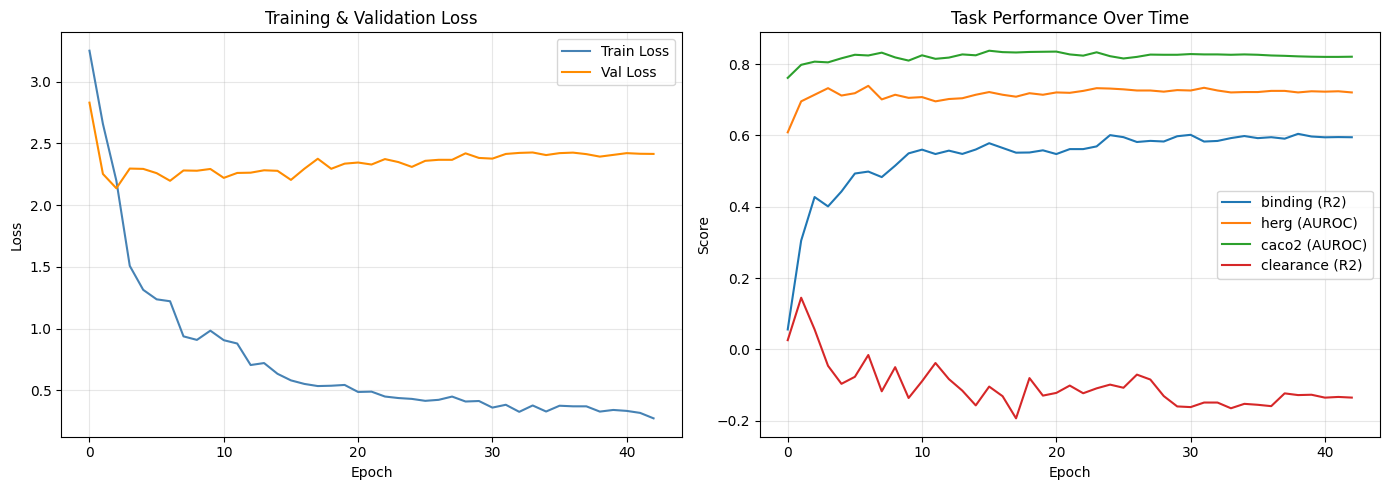


Final Validation Metrics:
Task         Metric      Value    Target
------------------------------------------
  binding    R²          0.595     >0.60
  herg       AUROC       0.721     >0.80
  caco2      AUROC       0.821     >0.75
  clearance  RMSE        0.860      <1.0
⏱  [2026-03-22 17:47:24] Completed in 3.8s


In [16]:

# ============================================
# RUN TRAINING
# ============================================
log_cell_start("Cell 21 - Training Run")

import time
t0 = time.time()

model, history = train_model(
    model,
    train_loaders,
    val_loaders,
    config,
    device
)

elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed:.1f}s")
log_elapsed("Training complete")

# ---- Visualise ----
plot_training_history(history)

log_cell_end()


⏱  [2026-03-22 17:47:38] Starting: Cell 22 - Results & Summary
Generating Neural ODE PK concentration-time curves...


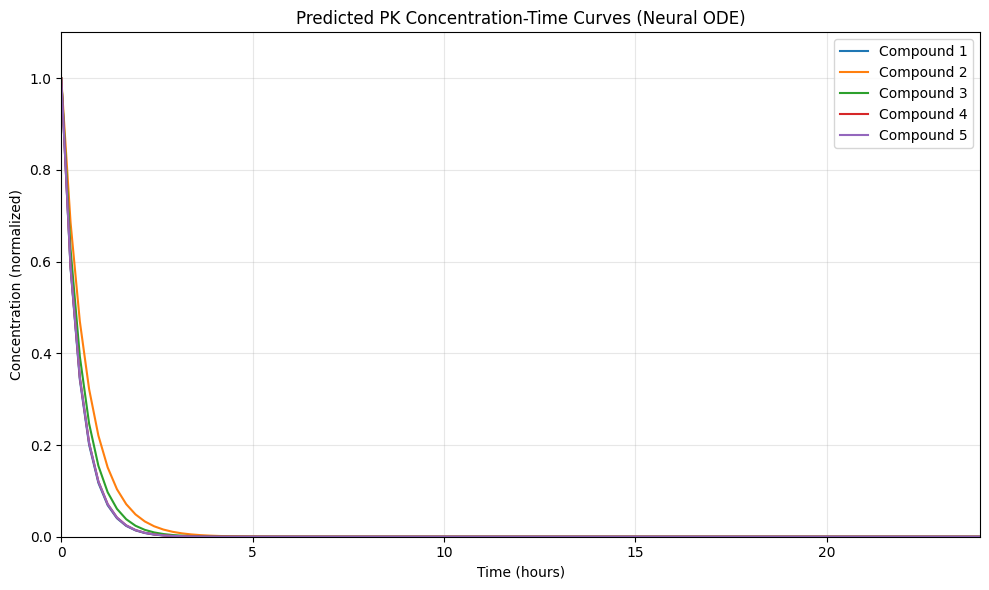

PK curves saved to 'pk_curves.png'

PHASE 3B STATUS SUMMARY

📊 ARCHITECTURE:
  - Multi-task Neural ODE (302,694 params)
  - 2051-dim features: 2 physico + 2048 ECFP4 fingerprints
    Physico features: ['MW', 'LogP']
  - LayerNorm encoder | Focal loss | Logits classification
  - Neural ODE PK curves via torchdiffeq
  - Early stopping (patience=40), LR scheduling

✅ TARGET MET (2/4):
  ✓ caco2      AUROC  = 0.821  (target >0.75)
  ✓ clearance  RMSE   = 0.860  (target <1.00)

⚠️  CLOSE / BORDERLINE (2/4):
  ~ binding    R²     = 0.595  (target >0.60)
  ~ herg       AUROC  = 0.721  (target >0.80)

📋 NEXT STEPS:
  1. Fine-tune with task-specific learning rates (phase3c)
  2. Add GNN molecular encoder for richer structural features
  3. Task-specific encoders for binding (no SMILES available)
  4. More training data via augmentation or larger TDC splits
⏱  [Session complete] Elapsed: 0h 1m 44s
⏱  [2026-03-22 17:47:39] Completed in 0.2s


In [17]:

# ============================================
# NEURAL ODE PK CURVE DEMO
# ============================================
log_cell_start("Cell 22 - Results & Summary")

# Sample 5 clearance test molecules for PK curve generation
X_clearance_all, _ = tasks_raw['clearance']
sample_X = torch.FloatTensor(
    feat_scalers['clearance'].transform(X_clearance_all[:5])
)

print("Generating Neural ODE PK concentration-time curves...")
plot_pk_curves(model, sample_X.numpy(), device, t_max=24, n_points=100)

# ============================================
# PHASE 3B STATUS SUMMARY  (fully dynamic)
# ============================================

final = history['val_metrics'][-1]

# Define targets per task
targets_meta = {
    'binding':   {'metric': 'R²',    'key': 'r2',    'target': 0.60, 'op': 'gt', 'fmt': '>0.60'},
    'herg':      {'metric': 'AUROC', 'key': 'auroc', 'target': 0.80, 'op': 'gt', 'fmt': '>0.80'},
    'caco2':     {'metric': 'AUROC', 'key': 'auroc', 'target': 0.75, 'op': 'gt', 'fmt': '>0.75'},
    'clearance': {'metric': 'RMSE',  'key': 'rmse',  'target': 1.00, 'op': 'lt', 'fmt': '<1.00'},
}

met, partial, not_met = [], [], []
for task, meta in targets_meta.items():
    val = final[task][meta['key']]
    hit = (val < meta['target']) if meta['op'] == 'lt' else (val > meta['target'])
    # "Partial" = within 10% of the target threshold
    if meta['op'] == 'lt':
        close = val < meta['target'] * 1.10
    else:
        close = val > meta['target'] * 0.90
    entry = f"{task:<10} {meta['metric']:<6} = {val:.3f}  (target {meta['fmt']})"
    if hit:
        met.append(entry)
    elif close:
        partial.append(entry)
    else:
        not_met.append(entry)

print("\n" + "=" * 65)
print("PHASE 3B STATUS SUMMARY")
print("=" * 65)

print("\n📊 ARCHITECTURE:")
print(f"  - Multi-task Neural ODE ({total_params:,} params)")
print(f"  - {FEAT_DIM}-dim features: {len(PHYSICO_FEATURES)} physico + {N_BITS} ECFP4 fingerprints")
print(f"    Physico features: {PHYSICO_FEATURES}")
print("  - LayerNorm encoder | Focal loss | Logits classification")
print("  - Neural ODE PK curves via torchdiffeq")
print(f"  - Early stopping (patience={config['patience']}), LR scheduling")

if met:
    print(f"\n✅ TARGET MET ({len(met)}/{len(targets_meta)}):")
    for e in met:
        print(f"  ✓ {e}")

if partial:
    print(f"\n⚠️  CLOSE / BORDERLINE ({len(partial)}/{len(targets_meta)}):")
    for e in partial:
        print(f"  ~ {e}")

if not_met:
    print(f"\n❌ NOT YET MET ({len(not_met)}/{len(targets_meta)}):")
    for e in not_met:
        print(f"  ✗ {e}")

print(f"\n📋 NEXT STEPS:")
print("  1. Fine-tune with task-specific learning rates (phase3c)")
print("  2. Add GNN molecular encoder for richer structural features")
print("  3. Task-specific encoders for binding (no SMILES available)")
print("  4. More training data via augmentation or larger TDC splits")
print("=" * 65)
log_elapsed("Session complete")

log_cell_end()


---
## Save Phase 3B Artifacts

Save trained model, training history, and all runtime state needed by
`phase3c_finetuning.ipynb`.


In [18]:

# ============================================
# SAVE PHASE 3B ARTIFACTS FOR PHASE 3C
# ============================================
log_cell_start("Cell 23 - Save Artifacts")

import pickle, os

ARTIFACT_DIR_3B = 'data/processed/phase3b_artifacts'
os.makedirs(ARTIFACT_DIR_3B, exist_ok=True)

# 1. Save trained model state dict
torch.save(model.state_dict(), os.path.join(ARTIFACT_DIR_3B, 'model_state.pt'))

# 2. Save training history
with open(os.path.join(ARTIFACT_DIR_3B, 'history.pkl'), 'wb') as f:
    pickle.dump(history, f)

# 3. Save config (may have been updated during training)
import json as _json
with open(os.path.join(ARTIFACT_DIR_3B, 'config.json'), 'w') as f:
    _json.dump(config, f, indent=2)

# 4. Save DataLoaders components
loader_state = {
    'tasks_raw': tasks_raw,
    'task_types': task_types,
    'feat_scalers': feat_scalers,
    'target_scalers': target_scalers,
}
with open(os.path.join(ARTIFACT_DIR_3B, 'loader_state.pkl'), 'wb') as f:
    pickle.dump(loader_state, f)

# 5. Save feature metadata
feature_meta_3b = {
    'FEATURE_COLS': FEATURE_COLS,
    'PHYSICO_FEATURES': PHYSICO_FEATURES,
    'FINGERPRINT_COLS': FINGERPRINT_COLS,
    'N_BITS': N_BITS,
    'FEAT_DIM': FEAT_DIM,
}
with open(os.path.join(ARTIFACT_DIR_3B, 'feature_meta.pkl'), 'wb') as f:
    pickle.dump(feature_meta_3b, f)

# 6. Save total_params for summary
with open(os.path.join(ARTIFACT_DIR_3B, 'model_info.pkl'), 'wb') as f:
    pickle.dump({'total_params': total_params, 'trainable_params': trainable_params}, f)

# 7. Save raw task arrays from tasks_raw for downstream use
raw_arrays = {}
for task_name, (X_arr, y_arr) in tasks_raw.items():
    raw_arrays[f'X_{task_name}'] = X_arr
    raw_arrays[f'y_{task_name}'] = y_arr
with open(os.path.join(ARTIFACT_DIR_3B, 'raw_arrays.pkl'), 'wb') as f:
    pickle.dump(raw_arrays, f)

# 8. Save phase2_features path
with open(os.path.join(ARTIFACT_DIR_3B, 'phase2_path.txt'), 'w') as f:
    f.write('data/processed/phase3a_artifacts/phase2_features.parquet')

print(f'\n✅ Phase 3B artifacts saved to {ARTIFACT_DIR_3B}/')
for fname in sorted(os.listdir(ARTIFACT_DIR_3B)):
    fsize = os.path.getsize(os.path.join(ARTIFACT_DIR_3B, fname))
    print(f'  {fname:40s} {fsize/1024:.1f} KB')
print('\n➡️  Continue with phase3c_finetuning.ipynb')

log_cell_end()


⏱  [2026-03-22 17:47:43] Starting: Cell 23 - Save Artifacts

✅ Phase 3B artifacts saved to data/processed/phase3b_artifacts/
  config.json                              0.5 KB
  feature_meta.pkl                         29.4 KB
  history.pkl                              16.6 KB
  loader_state.pkl                         49714.4 KB
  model_info.pkl                           0.1 KB
  model_state.pt                           1194.0 KB
  phase2_path.txt                          0.1 KB
  raw_arrays.pkl                           49521.0 KB

➡️  Continue with phase3c_finetuning.ipynb
⏱  [2026-03-22 17:47:43] Completed in 0.1s


---
## Phase 3B Execution Timeline Summary


In [19]:

# ============================================
# PHASE 3B — EXECUTION TIMELINE SUMMARY
# ============================================
import datetime

print("=" * 88)
print("  PHASE 3B — CELL EXECUTION TIMELINE")
print("=" * 88)

if not CELL_EXEC_LOG:
    print("  (no cells logged yet)")
else:
    print(f"  {'#':<4} {'Section':<45} {'Start':>8}  {'End':>8}  {'Dur (s)':>8}")
    print("-" * 88)
    total_compute = 0.0
    for i, entry in enumerate(CELL_EXEC_LOG, 1):
        start_str = entry['start'].strftime('%H:%M:%S') if entry['start'] else '—'
        end_str   = entry['end'].strftime('%H:%M:%S') if entry['end'] else 'running…'
        dur_str   = f"{entry['duration_s']:.1f}" if entry['duration_s'] is not None else '—'
        if entry['duration_s'] is not None:
            total_compute += entry['duration_s']
        section = entry['section'][:44]
        print(f"  {i:<4} {section:<45} {start_str:>8}  {end_str:>8}  {dur_str:>8}")
    print("-" * 88)

    # Totals
    wall_clock = (datetime.datetime.now() - SESSION_START).total_seconds()
    h_c, rem_c = divmod(int(total_compute), 3600)
    m_c, s_c   = divmod(rem_c, 60)
    h_w, rem_w = divmod(int(wall_clock), 3600)
    m_w, s_w   = divmod(rem_w, 60)

    print(f"  {'Total compute time:':<55} {h_c}h {m_c}m {s_c}s  ({total_compute:.1f}s)")
    print(f"  {'Wall-clock time (session start → now):':<55} {h_w}h {m_w}m {s_w}s  ({wall_clock:.1f}s)")
    print(f"  {'Session started:':<55} {SESSION_START.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  {'Summary generated:':<55} {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"  {'Cells logged:':<55} {len(CELL_EXEC_LOG)}")
print("=" * 88)


  PHASE 3B — CELL EXECUTION TIMELINE
  #    Section                                          Start       End   Dur (s)
----------------------------------------------------------------------------------------
  1    Load Phase 3A Artifacts                       17:45:54  17:45:54       0.2
  2    Bridge Augmentation: +docking_quality (2050   17:45:57  17:46:00       2.4
  3    Rebuild DataLoaders                           17:46:10  17:46:10       0.1
  4    Cell 09 - MultiTaskDataset                    17:46:17  17:46:17       0.0
  5    Cell 10 - Shared Encoder                      17:46:20  17:46:20       0.0
  6    Cell 11 - Task Heads                          17:46:23  17:46:23       0.0
  7    Cell 12 - PKODEFunc                           17:46:26  17:46:26       0.0
  8    Cell 13 - Full Model                          17:46:29  17:46:29       0.0
  9    Cell 14 - Instantiate Model                   17:46:32  17:46:32       0.0
  10   Cell 15 - MultiTaskLoss                       1

---
## 10. Presentation Material (Mixed Format: Bullets + Tables)

### Project Overview
- Phase 3B builds a multi-task Neural PK-PD model with a Neural ODE module.
- Objective: combine endpoint prediction performance with mechanistic PK behavior.
- This deck section is intentionally mixed format: bullets for flow, tables for dense technical details.

### Problem and Theory
- Multi-task learning shares statistical strength across binding, hERG, Caco-2, and clearance.
- Neural ODE allows continuous-time PK trajectory prediction instead of only scalar endpoints.
- Physics-inspired structure improves plausibility and interpretability.

| Theory Element | Why Used | Practical Benefit |
|---|---|---|
| Shared encoder | Transfer learning across tasks | Better data efficiency |
| Task-specific heads | Preserve endpoint specialization | Better per-task fit |
| Neural ODE | Continuous-time dynamics | Flexible PK curve prediction |
| Physics-informed form | Mechanistic constraints | More plausible concentration profiles |

### Data and Feature Pipeline
- Input features combine descriptors, fingerprints, and docking_quality.
- The bridge feature injects structure-derived signal into downstream learning.
- A unified input schema is maintained for all tasks.

| Stage | Input | Operation | Output |
|---|---|---|---|
| Artifact load | Phase 3A + bridge outputs | Validate and merge | Task arrays + metadata |
| Feature build | Descriptors + FP + docking_quality | Align schema | Unified matrix |
| Split and scale | Task arrays | Train/Val/Test + scaling | Model-ready loaders |

### Architecture and Rationale
- Shared encoder: two Linear+LayerNorm+ReLU+Dropout blocks and latent projection.
- Head design: deeper binding regression head, compact clearance head, logits classifiers.
- PKODEFunc predicts CL and V, then integrates dC/dt = -kC.
- LayerNorm is preferred over BatchNorm for interleaved multi-task stability.

| Module | Input | Output | Why This Choice |
|---|---|---|---|
| SharedEncoder | Features | Latent | Strong shared representation |
| DeepRegressionHead | Latent | Binding | Harder regression needs extra depth |
| ClassificationHead | Latent | hERG/Caco-2 logits | Stable training + calibration compatibility |
| PKODEFunc | Latent + C(t) | PK curve | Mechanistic concentration dynamics |

### Hyperparameters (Key)
- Important groups: architecture, optimization, loss weighting, class handling.

| Hyperparameter | Value | Role | Impact |
|---|---:|---|---|
| input_dim | 2051 | Input width | Capacity and memory footprint |
| hidden_dim / latent_dim | 128 / 64 | Encoder capacity | Representation power vs compression |
| dropout | 0.2 | Regularization | Generalization stability |
| batch_size | 64 | Batch granularity | Stable gradient estimates |
| learning_rate | 1e-3 | Step size | Convergence speed/stability |
| weight_decay | 1e-4 | L2 regularization | Controls parameter growth |
| epochs / patience | 300 / 40 | Training horizon | Avoids under/overtraining |
| grad_clip | 1.0 | Gradient control | Prevents unstable updates |
| focal_gamma | 2.0 | Hard-sample focus | Better minority learning |

### Training and Evaluation
- Training uses interleaved multi-task updates and minimum-batch epoch sizing.
- Loss combines weighted MSE and BCE/Focal logits with physics penalty.
- Evaluation uses RMSE/MAE/R2 for regression and AUROC/accuracy/F1 for classification.
- Validation thresholds are selected with Youden criterion.

### Visual Evidence
- Show `training_history.png` to discuss convergence and task plateaus.
- Show `pk_curves.png` to discuss CL/V-driven concentration-time behavior.

### Risks and Next Work
- Risks: task interference, imbalance sensitivity, and calibration drift.
- Phase 3C actions: task-specific tuning schedules, loss-weight sweeps, calibration checks.
- Status: baseline is stable and ready for controlled fine-tuning.

### Figure: training_history.png

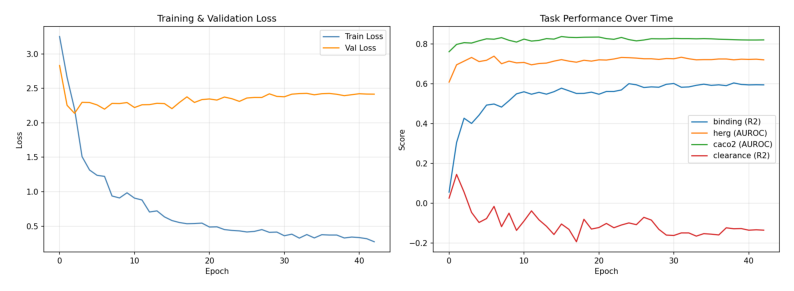

### Figure: pk_curves.png

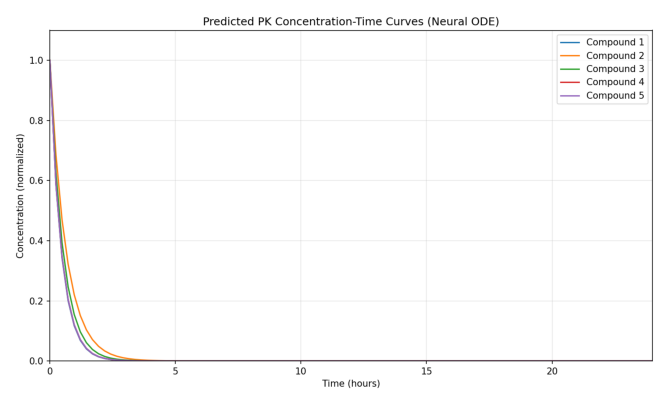

In [1]:
# ============================================
# PRESENTATION FIGURES: DISPLAY KEY IMAGES
# ============================================
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

fig_paths = [
    'training_history.png',
    'pk_curves.png',
]

for p in fig_paths:
    if os.path.exists(p):
        display(Markdown(f"### Figure: {p}"))
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    else:
        print(f"Missing figure: {p}. Run training/plot cells first.")